# 06 Build Features

## Purpose

Build feature tables required for later supervised recommendation and reorder prediction experiments.

This notebook uses the outputs of the earlier preprocessing and chronological split stages to create:

- user-level behavioural features
- item-level recipe and popularity features
- user-item interaction-history features
- Random Forest target labels for future reorder prediction

The feature-building design follows the earlier project plan:

- `04_build_modelling_datasets.ipynb` created modelling-ready datasets
- `05_make_chronological_splits.ipynb` created chronological train / validation / test splits
- `06_build_features.ipynb` now derives leakage-safe features using past behaviour only

## Objectives

- load split datasets and joined modelling data
- confirm the required columns and split date ranges
- build user feature tables
- build item feature tables
- build user-item historical features
- generate Random Forest labels
- assemble train / validation / test feature tables
- inspect nulls, distributions, and class balance
- save feature datasets and summary tables for later modelling

## Prior findings carried into this phase

Earlier notebooks established that:

- `RAW_recipes.csv` remains the base recipe catalogue
- `PP_recipes.csv` is used only as an enrichment layer
- joined modelling data preserve recipe-side metadata for downstream use
- chronological splitting must be respected to avoid temporal leakage
- later feature engineering should build on the split outputs rather than re-splitting the full data

This notebook therefore builds feature tables using training history as the main source of behavioural statistics, while preserving time-aware evaluation logic.

In [30]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)

In [31]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.paths import (
    PROCESSED_DIR,
    SPLITS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    LOGS_DIR,
    ensure_directories,
)

ensure_directories()
print("Output directories are ready.")

Output directories are ready.


## 1. Load split datasets and joined modelling data

This phase uses the chronological split outputs created.

The main inputs are:

- `explicit_train.parquet`
- `explicit_valid.parquet`
- `explicit_test.parquet`
- `implicit_train.parquet`
- `implicit_valid.parquet`
- `implicit_test.parquet`
- `joined_train.parquet`
- `joined_valid.parquet`
- `joined_test.parquet`

The joined split tables are especially important because they preserve recipe-side metadata needed for item and hybrid-ready features.

In [32]:
explicit_train = pd.read_parquet(SPLITS_DIR / "explicit_train.parquet")
explicit_valid = pd.read_parquet(SPLITS_DIR / "explicit_valid.parquet")
explicit_test = pd.read_parquet(SPLITS_DIR / "explicit_test.parquet")

implicit_train = pd.read_parquet(SPLITS_DIR / "implicit_train.parquet")
implicit_valid = pd.read_parquet(SPLITS_DIR / "implicit_valid.parquet")
implicit_test = pd.read_parquet(SPLITS_DIR / "implicit_test.parquet")

joined_train = pd.read_parquet(SPLITS_DIR / "joined_train.parquet")
joined_valid = pd.read_parquet(SPLITS_DIR / "joined_valid.parquet")
joined_test = pd.read_parquet(SPLITS_DIR / "joined_test.parquet")

print("Explicit train shape:", explicit_train.shape)
print("Explicit valid shape:", explicit_valid.shape)
print("Explicit test shape:", explicit_test.shape)

print("Implicit train shape:", implicit_train.shape)
print("Implicit valid shape:", implicit_valid.shape)
print("Implicit test shape:", implicit_test.shape)

print("Joined train shape:", joined_train.shape)
print("Joined valid shape:", joined_valid.shape)
print("Joined test shape:", joined_test.shape)

Explicit train shape: (750064, 9)
Explicit valid shape: (160728, 9)
Explicit test shape: (160728, 9)
Implicit train shape: (792656, 9)
Implicit valid shape: (169855, 9)
Implicit test shape: (169856, 9)
Joined train shape: (792656, 24)
Joined valid shape: (169855, 24)
Joined test shape: (169856, 24)


In [33]:
display(explicit_train.head(3))
display(implicit_train.head(3))
display(joined_train.head(3))

,user_id,recipe_id,date,rating,explicit_rating,review_exists,implicit_feedback,user_idx,item_idx
0,2008,992,2000-01-25,5,5,1,1,10,391
1,2008,3603,2000-01-25,4,4,1,1,10,1107
2,2046,517,2000-02-25,5,5,1,1,12,234


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,2008,992,2000-01-25,5,1,0,1,11,410
1,2008,3603,2000-01-25,4,1,0,1,11,1154
2,2046,517,2000-02-25,5,1,0,1,13,250


,user_id,recipe_id,date,rating,explicit_rating,review_exists,is_unrated_observation,implicit_feedback,name,minutes,submitted,n_steps,n_ingredients,name_length,description_length,tag_count,step_count_from_list,ingredient_count_from_list,nutrition_vector_length,nutrition_sum,nutrition_mean,has_description,calorie_level,has_pp_features
0,2008,992,2000-01-25,5,5.0,1,0,1,jalapeno pepper poppers,30,1999-09-06,11,10,23,40,12,11,10,7,168.4,24.057143,1,0,1.0
1,2008,3603,2000-01-25,4,4.0,1,0,1,hooters buffalo wings,27,1999-09-24,16,12,21,55,28,16,12,7,1257.1,179.585714,1,<NA>,NaN
2,2046,517,2000-02-25,5,5.0,1,0,1,greek stuffed meatloaf,149,1999-08-23,15,20,22,41,20,15,20,7,555.4,79.342857,1,1,1.0


## 2. Confirm required columns and date ranges

Before feature engineering begins, the split datasets are checked for:

- identifier columns
- date columns
- interaction signal columns
- recipe-side metadata columns in the joined tables

This phase will mainly use the joined split tables for feature construction, because they include both behavioural and recipe-side information.

In [34]:
print("Joined train columns:")
print(joined_train.columns.tolist())

required_cols = [
    "user_id",
    "recipe_id",
    "date",
    "implicit_feedback",
]

missing_required = [col for col in required_cols if col not in joined_train.columns]
print("\nMissing required columns:", missing_required)

print("\nTrain date range:", joined_train["date"].min(), "to", joined_train["date"].max())
print("Valid date range:", joined_valid["date"].min(), "to", joined_valid["date"].max())
print("Test date range:", joined_test["date"].min(), "to", joined_test["date"].max())

Joined train columns:
['user_id', 'recipe_id', 'date', 'rating', 'explicit_rating', 'review_exists', 'is_unrated_observation', 'implicit_feedback', 'name', 'minutes', 'submitted', 'n_steps', 'n_ingredients', 'name_length', 'description_length', 'tag_count', 'step_count_from_list', 'ingredient_count_from_list', 'nutrition_vector_length', 'nutrition_sum', 'nutrition_mean', 'has_description', 'calorie_level', 'has_pp_features']

Missing required columns: []

Train date range: 2000-01-25 00:00:00 to 2010-06-17 00:00:00
Valid date range: 2010-06-17 00:00:00 to 2012-12-28 00:00:00
Test date range: 2012-12-28 00:00:00 to 2018-12-20 00:00:00


## 3. Define feature-building helpers

The goal is to derive three broad feature groups:

- user features
- item features
- user-item historical features

Because the project plan frames Random Forest as a supervised reorder prediction model, the feature logic should reflect prior behaviour and interaction history rather than future information.

A key rule in this notebook is:

> all aggregate features for validation and test must be derived from training history only, or from prior interactions available up to the observation point.

This keeps the pipeline temporally realistic and leakage-safe.

In [35]:
def safe_divide(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b


def days_between(later, earlier):
    if pd.isna(later) or pd.isna(earlier):
        return np.nan
    return (later - earlier).days


def ensure_datetime_column(df: pd.DataFrame, col: str) -> pd.DataFrame:
    out = df.copy()
    out[col] = pd.to_datetime(out[col], errors="coerce")
    return out

In [36]:
joined_train = ensure_datetime_column(joined_train, "date")
joined_valid = ensure_datetime_column(joined_valid, "date")
joined_test = ensure_datetime_column(joined_test, "date")

for df in (joined_train, joined_valid, joined_test):
    df.sort_values(["user_id", "recipe_id", "date"], inplace=True)
    df.reset_index(drop=True, inplace=True)

## 4. Build user feature table from training history

User features summarise behavioural tendencies observed in the training split.

Suggested user-level features include:

- total prior interactions
- number of distinct recipes interacted with
- mean explicit rating
- rating count
- unrated-observation count
- review rate
- active span in days
- average interactions per active day
- most recent interaction date in train

These features help Random Forest capture user activity level and historical engagement intensity.

In [37]:
user_features_train = (
    joined_train.groupby("user_id", dropna=False)
    .agg(
        user_total_interactions=("recipe_id", "size"),
        user_distinct_recipes=("recipe_id", "nunique"),
        user_mean_rating=("explicit_rating", "mean"),
        user_rating_count=("explicit_rating", lambda s: s.notna().sum()),
        user_review_rate=("review_exists", "mean"),
        user_unrated_count=("is_unrated_observation", "sum"),
        user_first_date=("date", "min"),
        user_last_date=("date", "max"),
    )
    .reset_index()
)

user_features_train["user_active_days"] = (
    user_features_train["user_last_date"] - user_features_train["user_first_date"]
).dt.days + 1

user_features_train["user_interactions_per_day"] = (
    user_features_train["user_total_interactions"] /
    user_features_train["user_active_days"].replace(0, np.nan)
)

display(user_features_train.head())
print("User feature table shape:", user_features_train.shape)

,user_id,user_total_interactions,user_distinct_recipes,user_mean_rating,user_rating_count,user_review_rate,user_unrated_count,user_first_date,user_last_date,user_active_days,user_interactions_per_day
0,1533,128,128,4.710938,128,1.0,0,2002-02-19,2008-03-01,2203,0.058103
1,1535,668,668,4.490964,664,1.0,4,2004-05-22,2010-05-26,2196,0.304189
2,1634,59,59,4.240000,50,1.0,9,2001-07-02,2010-02-05,3141,0.018784
3,1676,27,27,4.629630,27,1.0,0,2002-07-24,2010-04-23,2831,0.009537
4,1755,2,2,4.500000,2,1.0,0,2002-10-25,2002-12-23,60,0.033333


User feature table shape: (106304, 11)


## 5. Build item feature table from training history and recipe metadata

Item features combine:

- behavioural signals from training interactions
- static recipe-side metadata already prepared in earlier phases

Behavioural item features reflect how popular or well-rated an item has historically been.
Metadata features reflect recipe characteristics such as preparation time, ingredient count, steps, tags, nutrition summaries, and PP-derived enrichment where available.

In [38]:
item_behaviour_train = (
    joined_train.groupby("recipe_id", dropna=False)
    .agg(
        item_total_interactions=("user_id", "size"),
        item_distinct_users=("user_id", "nunique"),
        item_mean_rating=("explicit_rating", "mean"),
        item_rating_count=("explicit_rating", lambda s: s.notna().sum()),
        item_review_rate=("review_exists", "mean"),
        item_unrated_count=("is_unrated_observation", "sum"),
        item_first_date=("date", "min"),
        item_last_date=("date", "max"),
    )
    .reset_index()
)

item_behaviour_train["item_active_days"] = (
    item_behaviour_train["item_last_date"] - item_behaviour_train["item_first_date"]
).dt.days + 1

item_behaviour_train["item_interactions_per_day"] = (
    item_behaviour_train["item_total_interactions"] /
    item_behaviour_train["item_active_days"].replace(0, np.nan)
)

item_behaviour_train["item_popularity_rank"] = (
    item_behaviour_train["item_total_interactions"]
    .rank(method="dense", ascending=False)
    .astype("Int64")
)

display(item_behaviour_train.head())
print("Item behavioural feature shape:", item_behaviour_train.shape)

,recipe_id,item_total_interactions,item_distinct_users,item_mean_rating,item_rating_count,item_review_rate,item_unrated_count,item_first_date,item_last_date,item_active_days,item_interactions_per_day,item_popularity_rank
0,38,2,2,4.500000,2,1.0,0,2008-02-13,2009-01-15,338,0.005917,281
1,39,1,1,3.000000,1,1.0,0,2007-01-20,2007-01-20,1,1.000000,282
2,40,9,9,4.333333,9,1.0,0,2002-12-18,2010-05-23,2714,0.003316,274
3,41,2,2,4.500000,2,1.0,0,2003-04-13,2009-01-26,2116,0.000945,281
4,43,1,1,1.000000,1,1.0,0,2009-02-07,2009-02-07,1,1.000000,282


Item behavioural feature shape: (186564, 12)


In [39]:
recipe_static_core_cols = [
    "recipe_id",
    "minutes",
    "n_steps",
    "n_ingredients",
    "name_length",
    "description_length",
    "tag_count",
    "step_count_from_list",
    "ingredient_count_from_list",
    "nutrition_vector_length",
    "nutrition_sum",
    "nutrition_mean",
    "has_description",
]

recipe_static_pp_cols = [
    "i",
    "calorie_level",
    "name_token_count",
    "ingredient_token_group_count",
    "step_token_count",
    "technique_vector_length",
    "technique_count_active",
    "ingredient_id_count",
    "has_pp_features",
]

recipe_static_tag_cols = [
    "tag_breakfast",
    "tag_lunch",
    "tag_dinner",
    "tag_dessert",
    "tag_healthy",
    "tag_easy",
    "tag_vegetarian",
    "tag_vegan",
]

recipe_static_cols_desired = (
    recipe_static_core_cols
    + recipe_static_pp_cols
    + recipe_static_tag_cols
)

In [40]:
recipe_static_cols_available = [
    col for col in recipe_static_cols_desired
    if col in joined_train.columns
]

recipe_static_cols_missing = [
    col for col in recipe_static_cols_desired
    if col not in joined_train.columns
]

print("Available recipe static columns:")
print(recipe_static_cols_available)

print("\nMissing recipe static columns:")
print(recipe_static_cols_missing)

Available recipe static columns:
['recipe_id', 'minutes', 'n_steps', 'n_ingredients', 'name_length', 'description_length', 'tag_count', 'step_count_from_list', 'ingredient_count_from_list', 'nutrition_vector_length', 'nutrition_sum', 'nutrition_mean', 'has_description', 'calorie_level', 'has_pp_features']

Missing recipe static columns:
['i', 'name_token_count', 'ingredient_token_group_count', 'step_token_count', 'technique_vector_length', 'technique_count_active', 'ingredient_id_count', 'tag_breakfast', 'tag_lunch', 'tag_dinner', 'tag_dessert', 'tag_healthy', 'tag_easy', 'tag_vegetarian', 'tag_vegan']


In [41]:
recipe_static_features = (
    joined_train[recipe_static_cols_available]
    .drop_duplicates(subset=["recipe_id"])
    .copy()
)

print("Recipe static feature shape:", recipe_static_features.shape)
display(recipe_static_features.head())

Recipe static feature shape: (186564, 15)


,recipe_id,minutes,n_steps,n_ingredients,name_length,description_length,tag_count,step_count_from_list,ingredient_count_from_list,nutrition_vector_length,nutrition_sum,nutrition_mean,has_description,calorie_level,has_pp_features
0,2137,40,17,8,17,39,19,17,8,7,380.9,54.414286,1,0,1.0
1,8857,60,10,8,11,63,19,10,8,7,370.5,52.928571,1,1,1.0
2,10332,45,12,10,29,264,19,12,10,7,682.1,97.442857,1,1,1.0
3,10554,23,5,5,18,266,13,5,5,7,48.3,6.900000,1,0,1.0
4,10721,40,3,4,19,50,16,3,4,7,381.3,54.471429,1,0,1.0


In [42]:
item_features_train = item_behaviour_train.merge(
    recipe_static_features,
    on="recipe_id",
    how="left",
    validate="one_to_one",
)

display(item_features_train.head())
print("Final item feature table shape:", item_features_train.shape)

,recipe_id,item_total_interactions,item_distinct_users,item_mean_rating,item_rating_count,item_review_rate,item_unrated_count,item_first_date,item_last_date,item_active_days,item_interactions_per_day,item_popularity_rank,minutes,n_steps,n_ingredients,name_length,description_length,tag_count,step_count_from_list,ingredient_count_from_list,nutrition_vector_length,nutrition_sum,nutrition_mean,has_description,calorie_level,has_pp_features
0,38,2,2,4.500000,2,1.0,0,2008-02-13,2009-01-15,338,0.005917,281,1485,13,4,33,55,26,13,4,7,318.9,45.557143,1,0,1.0
1,39,1,1,3.000000,1,1.0,0,2007-01-20,2007-01-20,1,1.000000,282,265,17,26,7,12,19,17,26,7,1532.7,218.957143,1,<NA>,NaN
2,40,9,9,4.333333,9,1.0,0,2002-12-18,2010-05-23,2714,0.003316,274,35,8,6,13,350,19,8,6,7,646.1,92.300000,1,1,1.0
3,41,2,2,4.500000,2,1.0,0,2003-04-13,2009-01-26,2116,0.000945,281,1460,18,15,30,104,29,18,15,7,862.1,123.157143,1,<NA>,NaN
4,43,1,1,1.000000,1,1.0,0,2009-02-07,2009-02-07,1,1.000000,282,140,35,15,20,25,14,35,15,7,733.9,104.842857,1,<NA>,NaN


Final item feature table shape: (186564, 26)


## 5.1 Inspect item feature availability

The joined recipe table preserves the full raw recipe catalogue and enriches matching recipes with PP-derived features.
Some PP-side fields may be missing for recipes without a `PP_recipes.csv` match.
Optional tag-indicator columns may also be absent if they were not persisted in the saved preprocessing output.

In [43]:
item_feature_null_summary = pd.DataFrame({
    "column": item_features_train.columns,
    "null_count": item_features_train.isna().sum().values,
    "null_percentage": (
        item_features_train.isna().sum().values / len(item_features_train) * 100
    ).round(4),
}).sort_values(
    by=["null_count", "null_percentage"],
    ascending=False,
).reset_index(drop=True)

display(item_feature_null_summary.head(20))

,column,null_count,null_percentage
0,calorie_level,37365,20.0280
1,has_pp_features,37365,20.0280
2,description_length,4737,2.5391
3,item_mean_rating,3046,1.6327
4,name_length,1,0.0005
5,recipe_id,0,0.0000
6,item_total_interactions,0,0.0000
7,item_distinct_users,0,0.0000
8,item_rating_count,0,0.0000
9,item_review_rate,0,0.0000


## 6. Build user-item historical features on the training split

User-item features should describe the relationship between a specific user and a specific recipe before or at the current observation.

Examples include:

- prior interaction count for the pair
- prior explicit mean rating for the pair
- days since previous interaction with the same item
- whether the pair has been seen before
- cumulative reorder count before the current event

These are the most important supervised signals for reorder prediction.

In [44]:
train_pairs = joined_train.copy()
train_pairs = train_pairs.sort_values(["user_id", "recipe_id", "date"]).reset_index(drop=True)

train_pairs["ui_prior_interactions"] = (
    train_pairs.groupby(["user_id", "recipe_id"]).cumcount()
)

train_pairs["ui_seen_before"] = (train_pairs["ui_prior_interactions"] > 0).astype("int8")

train_pairs["ui_prior_explicit_rating_mean"] = (
    train_pairs.groupby(["user_id", "recipe_id"])["explicit_rating"]
    .transform(lambda s: s.shift().expanding().mean())
)

train_pairs["ui_previous_date"] = (
    train_pairs.groupby(["user_id", "recipe_id"])["date"].shift(1)
)

train_pairs["ui_days_since_last_interaction"] = (
    train_pairs["date"] - train_pairs["ui_previous_date"]
).dt.days

train_pairs["ui_prior_reorder_count"] = (
    train_pairs.groupby(["user_id", "recipe_id"]).cumcount()
)

display(
    train_pairs[
        [
            "user_id",
            "recipe_id",
            "date",
            "ui_prior_interactions",
            "ui_seen_before",
            "ui_prior_explicit_rating_mean",
            "ui_days_since_last_interaction",
            "ui_prior_reorder_count",
        ]
    ].head(10)
)

,user_id,recipe_id,date,ui_prior_interactions,ui_seen_before,ui_prior_explicit_rating_mean,ui_days_since_last_interaction,ui_prior_reorder_count
0,1533,2137,2005-02-27,0,0,NaN,NaN,0
1,1533,8857,2002-08-23,0,0,NaN,NaN,0
2,1533,10332,2005-02-09,0,0,NaN,NaN,0
3,1533,10554,2002-11-14,0,0,NaN,NaN,0
4,1533,10721,2002-05-02,0,0,NaN,NaN,0
5,1533,11914,2003-09-21,0,0,NaN,NaN,0
6,1533,13201,2003-09-28,0,0,NaN,NaN,0
7,1533,13813,2005-05-05,0,0,NaN,NaN,0
8,1533,14338,2003-09-25,0,0,NaN,NaN,0
9,1533,14419,2005-01-28,0,0,NaN,NaN,0


## 7. Generate Random Forest target labels on the training split

The project plan frames Random Forest as a supervised reorder prediction model.

A practical label for this project is:

- `rf_target_reordered_later = 1` if the same user interacts with the same recipe again after the current observation
- `rf_target_reordered_later = 0` otherwise

This label turns interaction history into a reorder-likelihood task that can later be used for ranked recommendation generation.

In [45]:
train_pairs["ui_next_date"] = (
    train_pairs.groupby(["user_id", "recipe_id"])["date"].shift(-1)
)

train_pairs["rf_target_reordered_later"] = (
    train_pairs["ui_next_date"].notna().astype("int8")
)

display(
    train_pairs[
        [
            "user_id",
            "recipe_id",
            "date",
            "ui_next_date",
            "rf_target_reordered_later",
        ]
    ].head(10)
)

print(train_pairs["rf_target_reordered_later"].value_counts(dropna=False))
print(train_pairs["rf_target_reordered_later"].value_counts(normalize=True, dropna=False))

,user_id,recipe_id,date,ui_next_date,rf_target_reordered_later
0,1533,2137,2005-02-27,NaT,0
1,1533,8857,2002-08-23,NaT,0
2,1533,10332,2005-02-09,NaT,0
3,1533,10554,2002-11-14,NaT,0
4,1533,10721,2002-05-02,NaT,0
5,1533,11914,2003-09-21,NaT,0
6,1533,13201,2003-09-28,NaT,0
7,1533,13813,2005-05-05,NaT,0
8,1533,14338,2003-09-25,NaT,0
9,1533,14419,2005-01-28,NaT,0


rf_target_reordered_later
0    792656
Name: count, dtype: int64
rf_target_reordered_later
0    1.0
Name: proportion, dtype: float64


## 8. Assemble the training feature table

The training feature table is built by joining:

- row-level user-item history features
- user-level aggregate features
- item-level behavioural and recipe metadata features

This table is the main output for later Random Forest modelling.

In [46]:
rf_train_features = (
    train_pairs.merge(user_features_train, on="user_id", how="left")
    .merge(item_features_train, on="recipe_id", how="left")
)

display(rf_train_features.head(3))
print("RF train feature shape:", rf_train_features.shape)

,user_id,recipe_id,date,rating,explicit_rating,review_exists,is_unrated_observation,implicit_feedback,name,minutes_x,submitted,n_steps_x,n_ingredients_x,name_length_x,description_length_x,tag_count_x,step_count_from_list_x,ingredient_count_from_list_x,nutrition_vector_length_x,nutrition_sum_x,nutrition_mean_x,has_description_x,calorie_level_x,has_pp_features_x,ui_prior_interactions,ui_seen_before,ui_prior_explicit_rating_mean,ui_previous_date,ui_days_since_last_interaction,ui_prior_reorder_count,ui_next_date,rf_target_reordered_later,user_total_interactions,user_distinct_recipes,user_mean_rating,user_rating_count,user_review_rate,user_unrated_count,user_first_date,user_last_date,user_active_days,user_interactions_per_day,item_total_interactions,item_distinct_users,item_mean_rating,item_rating_count,item_review_rate,item_unrated_count,item_first_date,item_last_date,item_active_days,item_interactions_per_day,item_popularity_rank,minutes_y,n_steps_y,n_ingredients_y,name_length_y,description_length_y,tag_count_y,step_count_from_list_y,ingredient_count_from_list_y,nutrition_vector_length_y,nutrition_sum_y,nutrition_mean_y,has_description_y,calorie_level_y,has_pp_features_y
0,1533,2137,2005-02-27,5,5.0,1,0,1,fresh rhubarb pie,40,1999-10-13,17,8,17,39,19,17,8,7,380.9,54.414286,1,0,1.0,0,0,NaN,NaT,NaN,0,NaT,0,128,128,4.710938,128,1.0,0,2002-02-19,2008-03-01,2203,0.058103,27,27,4.833333,24,1.0,3,2002-04-29,2010-05-10,2934,0.009202,256,40,17,8,17,39,19,17,8,7,380.9,54.414286,1,0,1.0
1,1533,8857,2002-08-23,5,5.0,1,0,1,khasta roti,60,2001-04-29,10,8,11,63,19,10,8,7,370.5,52.928571,1,1,1.0,0,0,NaN,NaT,NaN,0,NaT,0,128,128,4.710938,128,1.0,0,2002-02-19,2008-03-01,2203,0.058103,6,6,5.000000,6,1.0,0,2002-08-23,2006-07-30,1438,0.004172,277,60,10,8,11,63,19,10,8,7,370.5,52.928571,1,1,1.0
2,1533,10332,2005-02-09,5,5.0,1,0,1,low fat tuna noodle casserole,45,2001-07-20,12,10,29,264,19,12,10,7,682.1,97.442857,1,1,1.0,0,0,NaN,NaT,NaN,0,NaT,0,128,128,4.710938,128,1.0,0,2002-02-19,2008-03-01,2203,0.058103,15,15,4.333333,15,1.0,0,2001-08-03,2008-10-09,2625,0.005714,268,45,12,10,29,264,19,12,10,7,682.1,97.442857,1,1,1.0


RF train feature shape: (792656, 67)


## 9. Build validation and test feature tables using train-derived aggregates

For validation and test:

- user features are mapped from training aggregates
- item features are mapped from training aggregates plus static recipe metadata
- user-item history features should use only prior information available from training history

To keep this phase manageable and leakage-safe, validation and test are feature-mapped from the training-derived aggregate tables. New unseen users or items remain missing and will be quantified explicitly.

In [47]:
train_pair_summary = (
    train_pairs.groupby(["user_id", "recipe_id"], dropna=False)
    .agg(
        ui_prior_interactions_train=("recipe_id", "size"),
        ui_prior_explicit_rating_mean_train=("explicit_rating", "mean"),
        ui_last_train_date=("date", "max"),
    )
    .reset_index()
)

display(train_pair_summary.head())
print("Train pair summary shape:", train_pair_summary.shape)

,user_id,recipe_id,ui_prior_interactions_train,ui_prior_explicit_rating_mean_train,ui_last_train_date
0,1533,2137,1,5.0,2005-02-27
1,1533,8857,1,5.0,2002-08-23
2,1533,10332,1,5.0,2005-02-09
3,1533,10554,1,5.0,2002-11-14
4,1533,10721,1,5.0,2002-05-02


Train pair summary shape: (792656, 5)


In [48]:
def build_holdout_feature_table(holdout_df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    out = holdout_df.copy()
    out = out.merge(user_features_train, on="user_id", how="left")
    out = out.merge(item_features_train, on="recipe_id", how="left")
    out = out.merge(train_pair_summary, on=["user_id", "recipe_id"], how="left")

    out["ui_seen_before"] = out["ui_prior_interactions_train"].fillna(0).gt(0).astype("int8")
    out["ui_days_since_last_interaction"] = (
        out["date"] - out["ui_last_train_date"]
    ).dt.days

    out["split_name"] = split_name
    return out

In [49]:
rf_valid_features = build_holdout_feature_table(joined_valid, "valid")
rf_test_features = build_holdout_feature_table(joined_test, "test")

rf_train_features["split_name"] = "train"

print("RF valid feature shape:", rf_valid_features.shape)
print("RF test feature shape:", rf_test_features.shape)

display(rf_valid_features.head(3))
display(rf_test_features.head(3))

RF valid feature shape: (169855, 65)
RF test feature shape: (169856, 65)


,user_id,recipe_id,date,rating,explicit_rating,review_exists,is_unrated_observation,implicit_feedback,name,minutes_x,submitted,n_steps_x,n_ingredients_x,name_length_x,description_length_x,tag_count_x,step_count_from_list_x,ingredient_count_from_list_x,nutrition_vector_length_x,nutrition_sum_x,nutrition_mean_x,has_description_x,calorie_level_x,has_pp_features_x,user_total_interactions,user_distinct_recipes,user_mean_rating,user_rating_count,user_review_rate,user_unrated_count,user_first_date,user_last_date,user_active_days,user_interactions_per_day,item_total_interactions,item_distinct_users,item_mean_rating,item_rating_count,item_review_rate,item_unrated_count,item_first_date,item_last_date,item_active_days,item_interactions_per_day,item_popularity_rank,minutes_y,n_steps_y,n_ingredients_y,name_length_y,description_length_y,tag_count_y,step_count_from_list_y,ingredient_count_from_list_y,nutrition_vector_length_y,nutrition_sum_y,nutrition_mean_y,has_description_y,calorie_level_y,has_pp_features_y,ui_prior_interactions_train,ui_prior_explicit_rating_mean_train,ui_last_train_date,ui_seen_before,ui_days_since_last_interaction,split_name
0,1535,10465,2012-01-02,5,5.0,1,0,1,quick easy broiled chicken,35,2001-07-28,9,6,28,113,18,9,6,7,247.2,35.314286,1,0,1.0,668.0,668.0,4.490964,664.0,1.0,4.0,2004-05-22,2010-05-26,2196.0,0.304189,6.0,6.0,4.333333,6.0,1.0,0.0,2001-08-05,2009-11-05,3015.0,0.001990,277,35,9,6,28,113,18,9,6,7,247.2,35.314286,1.0,0,1.0,NaN,NaN,NaT,0,NaN,valid
1,1535,19693,2011-06-21,5,5.0,1,0,1,low fat chocolate raspberry trifle,255,2002-02-14,10,6,34,126,10,10,6,7,549.3,78.471429,1,1,1.0,668.0,668.0,4.490964,664.0,1.0,4.0,2004-05-22,2010-05-26,2196.0,0.304189,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaT,0,NaN,valid
2,1535,28341,2010-10-09,5,5.0,1,0,1,french dip roast beef sandwiches,190,2002-05-13,8,6,32,167,25,8,6,7,611.5,87.357143,1,1,1.0,668.0,668.0,4.490964,664.0,1.0,4.0,2004-05-22,2010-05-26,2196.0,0.304189,23.0,23.0,4.739130,23.0,1.0,0.0,2002-10-19,2009-12-09,2609.0,0.008816,260,190,8,6,32,167,25,8,6,7,611.5,87.357143,1.0,1,1.0,NaN,NaN,NaT,0,NaN,valid


,user_id,recipe_id,date,rating,explicit_rating,review_exists,is_unrated_observation,implicit_feedback,name,minutes_x,submitted,n_steps_x,n_ingredients_x,name_length_x,description_length_x,tag_count_x,step_count_from_list_x,ingredient_count_from_list_x,nutrition_vector_length_x,nutrition_sum_x,nutrition_mean_x,has_description_x,calorie_level_x,has_pp_features_x,user_total_interactions,user_distinct_recipes,user_mean_rating,user_rating_count,user_review_rate,user_unrated_count,user_first_date,user_last_date,user_active_days,user_interactions_per_day,item_total_interactions,item_distinct_users,item_mean_rating,item_rating_count,item_review_rate,item_unrated_count,item_first_date,item_last_date,item_active_days,item_interactions_per_day,item_popularity_rank,minutes_y,n_steps_y,n_ingredients_y,name_length_y,description_length_y,tag_count_y,step_count_from_list_y,ingredient_count_from_list_y,nutrition_vector_length_y,nutrition_sum_y,nutrition_mean_y,has_description_y,calorie_level_y,has_pp_features_y,ui_prior_interactions_train,ui_prior_explicit_rating_mean_train,ui_last_train_date,ui_seen_before,ui_days_since_last_interaction,split_name
0,1535,10125,2014-02-07,5,5.0,1,0,1,soft batch chocolate chip cookies,23,2001-07-10,5,10,33,42,28,5,10,7,356.3,50.900000,1,0,1.0,668.0,668.0,4.490964,664.0,1.0,4.0,2004-05-22,2010-05-26,2196.0,0.304189,191.0,191.0,4.668449,187.0,1.0,4.0,2001-07-11,2010-06-10,3257.0,0.058643,100,23,5,10,33,42,28,5,10,7,356.3,50.900000,1.0,0,1.0,NaN,NaN,NaT,0,NaN,test
1,1535,16533,2013-09-05,5,5.0,1,0,1,braised red cabbage with red onion and apples,75,2002-01-01,6,10,45,192,36,6,10,7,370.8,52.971429,1,0,1.0,668.0,668.0,4.490964,664.0,1.0,4.0,2004-05-22,2010-05-26,2196.0,0.304189,23.0,23.0,4.789474,19.0,1.0,4.0,2002-03-26,2010-01-13,2851.0,0.008067,260,75,6,10,45,192,36,6,10,7,370.8,52.971429,1.0,0,1.0,NaN,NaN,NaT,0,NaN,test
2,1535,16901,2014-07-18,4,4.0,1,0,1,jicama chili sticks,5,2002-01-07,1,3,19,348,37,1,3,7,28.9,4.128571,1,<NA>,NaN,668.0,668.0,4.490964,664.0,1.0,4.0,2004-05-22,2010-05-26,2196.0,0.304189,29.0,29.0,4.481481,27.0,1.0,2.0,2002-01-22,2010-04-23,3014.0,0.009622,254,5,1,3,19,348,37,1,3,7,28.9,4.128571,1.0,<NA>,NaN,NaN,NaN,NaT,0,NaN,test


## 10. Inspect missingness and unseen coverage in holdout splits

Because user and item aggregates are fitted on training history only, validation and test may contain:

- unseen users
- unseen items
- unseen user-item pairs

These should be measured rather than silently removed.

In [50]:
holdout_missing_summary = pd.DataFrame(
    {
        "split": ["valid", "test"],
        "rows": [len(rf_valid_features), len(rf_test_features)],
        "missing_user_features": [
            rf_valid_features["user_total_interactions"].isna().sum(),
            rf_test_features["user_total_interactions"].isna().sum(),
        ],
        "missing_item_features": [
            rf_valid_features["item_total_interactions"].isna().sum(),
            rf_test_features["item_total_interactions"].isna().sum(),
        ],
        "unseen_user_item_pairs": [
            rf_valid_features["ui_prior_interactions_train"].isna().sum(),
            rf_test_features["ui_prior_interactions_train"].isna().sum(),
        ],
    }
)

display(holdout_missing_summary)

,split,rows,missing_user_features,missing_item_features,unseen_user_item_pairs
0,valid,169855,48346,43718,169855
1,test,169856,115885,43126,169856


## 11. Feature null summary

Before saving the final feature tables, it is useful to inspect column-level null counts. This is especially important for:

- PP-derived metadata fields
- user features for unseen users
- item features for unseen items
- pair-history features for new user-item combinations

In [51]:
feature_null_summary = pd.DataFrame({
    "column": rf_train_features.columns,
    "train_nulls": rf_train_features.isna().sum().values,
    "valid_nulls": rf_valid_features.reindex(columns=rf_train_features.columns, fill_value=np.nan).isna().sum().values,
    "test_nulls": rf_test_features.reindex(columns=rf_train_features.columns, fill_value=np.nan).isna().sum().values,
})

feature_null_summary = feature_null_summary.sort_values(
    by=["train_nulls", "valid_nulls", "test_nulls"],
    ascending=False,
).reset_index(drop=True)

display(feature_null_summary.head(20))

,column,train_nulls,valid_nulls,test_nulls
0,ui_prior_explicit_rating_mean,792656,169855,169856
1,ui_previous_date,792656,169855,169856
2,ui_days_since_last_interaction,792656,169855,169856
3,ui_next_date,792656,169855,169856
4,calorie_level_y,128217,64141,63950
5,has_pp_features_y,128217,64141,63950
6,calorie_level_x,128217,32014,37016
7,has_pp_features_x,128217,32014,37016
8,explicit_rating,23221,13697,23929
9,description_length_y,19815,45415,44853


## 12. Class balance for Random Forest training labels

The reorder target should be inspected before model training, since class imbalance is expected in reorder-style prediction tasks.

In [52]:
rf_label_summary = (
    rf_train_features["rf_target_reordered_later"]
    .value_counts(dropna=False)
    .rename_axis("label")
    .reset_index(name="count")
)

rf_label_summary["fraction"] = rf_label_summary["count"] / rf_label_summary["count"].sum()

display(rf_label_summary)

,label,count,fraction
0,0,792656,1.0


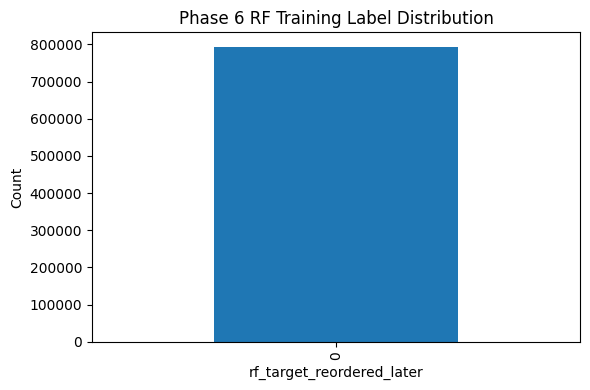

In [53]:
plt.figure(figsize=(6, 4))
rf_train_features["rf_target_reordered_later"].value_counts().sort_index().plot(kind="bar")
plt.title("Phase 6 RF Training Label Distribution")
plt.xlabel("rf_target_reordered_later")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_rf_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Save feature datasets

The main outputs of this phase are:

- user feature table
- item feature table
- Random Forest training feature table
- Random Forest validation feature table
- Random Forest test feature table

These outputs will support the next phase of model-ready exports and supervised model training.

In [54]:
user_features_train.to_parquet(PROCESSED_DIR / "features_user_train.parquet", index=False)
item_features_train.to_parquet(PROCESSED_DIR / "features_item_train.parquet", index=False)

rf_train_features.to_parquet(PROCESSED_DIR / "rf_train_features.parquet", index=False)
rf_valid_features.to_parquet(PROCESSED_DIR / "rf_valid_features.parquet", index=False)
rf_test_features.to_parquet(PROCESSED_DIR / "rf_test_features.parquet", index=False)

print("Feature datasets saved to:", PROCESSED_DIR)

Feature datasets saved to: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\processed


## 14. Save reporting tables

Compact reporting tables are also saved for later write-up use and pipeline debugging.

In [55]:
user_feature_summary = pd.DataFrame({
    "n_users_with_features": [user_features_train["user_id"].nunique()],
    "mean_user_total_interactions": [user_features_train["user_total_interactions"].mean()],
    "mean_user_distinct_recipes": [user_features_train["user_distinct_recipes"].mean()],
    "mean_user_mean_rating": [user_features_train["user_mean_rating"].mean()],
})

item_feature_summary = pd.DataFrame({
    "n_items_with_features": [item_features_train["recipe_id"].nunique()],
    "mean_item_total_interactions": [item_features_train["item_total_interactions"].mean()],
    "mean_item_distinct_users": [item_features_train["item_distinct_users"].mean()],
    "mean_item_mean_rating": [item_features_train["item_mean_rating"].mean()],
})

rf_dataset_summary = pd.DataFrame({
    "split": ["train", "valid", "test"],
    "rows": [len(rf_train_features), len(rf_valid_features), len(rf_test_features)],
    "users": [
        rf_train_features["user_id"].nunique(),
        rf_valid_features["user_id"].nunique(),
        rf_test_features["user_id"].nunique(),
    ],
    "recipes": [
        rf_train_features["recipe_id"].nunique(),
        rf_valid_features["recipe_id"].nunique(),
        rf_test_features["recipe_id"].nunique(),
    ],
})

user_feature_summary.to_csv(TABLES_DIR / "06_user_feature_summary.csv", index=False)
item_feature_summary.to_csv(TABLES_DIR / "06_item_feature_summary.csv", index=False)
holdout_missing_summary.to_csv(TABLES_DIR / "06_holdout_missing_summary.csv", index=False)
feature_null_summary.to_csv(TABLES_DIR / "06_feature_null_summary.csv", index=False)
rf_label_summary.to_csv(TABLES_DIR / "06_rf_label_summary.csv", index=False)
rf_dataset_summary.to_csv(TABLES_DIR / "06_rf_dataset_summary.csv", index=False)

print("Summary tables saved to:", TABLES_DIR)

Summary tables saved to: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables


## 15. Save compact JSON log

A compact JSON log is saved for later reporting and debugging.

In [56]:
log = {
    "user_feature_rows": int(len(user_features_train)),
    "item_feature_rows": int(len(item_features_train)),
    "rf_train_rows": int(len(rf_train_features)),
    "rf_valid_rows": int(len(rf_valid_features)),
    "rf_test_rows": int(len(rf_test_features)),
    "rf_train_positive_labels": int(rf_train_features["rf_target_reordered_later"].sum()),
    "rf_train_negative_labels": int((rf_train_features["rf_target_reordered_later"] == 0).sum()),
    "valid_missing_user_features": int(rf_valid_features["user_total_interactions"].isna().sum()),
    "valid_missing_item_features": int(rf_valid_features["item_total_interactions"].isna().sum()),
    "test_missing_user_features": int(rf_test_features["user_total_interactions"].isna().sum()),
    "test_missing_item_features": int(rf_test_features["item_total_interactions"].isna().sum()),
}

with open(LOGS_DIR / "06_feature_build_log.json", "w", encoding="utf-8") as f:
    json.dump(log, f, indent=2)

print("Log saved to:", LOGS_DIR / "06_feature_build_log.json")

Log saved to: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\logs\06_feature_build_log.json


### Random Forest (Attempted Approach and Exclusion)

A Random Forest model was initially proposed as a supervised learning approach to predict the likelihood of a user reordering a recipe, based on engineered user, item, and interaction-level features. These included behavioural statistics (e.g. prior interactions, user activity), item characteristics (e.g. nutrition, preparation time), and user–item interaction history.

However, after constructing the target variable (`rf_target_reordered_later`), it was observed that the dataset contained virtually no repeated user–recipe interactions. As a result, the reorder-based target collapsed to a single class, with all observations labelled as non-reordered. This made supervised learning infeasible, as the model could not distinguish between positive and negative examples.

Given the absence of a valid learning signal and the inability to generate meaningful ranked recommendations, Random Forest was excluded from the final comparative evaluation. Including it would have compromised the consistency and fairness of comparison across models.

Despite this, the exercise provided valuable insights into the dataset structure and highlighted the importance of aligning modelling assumptions with the underlying interaction patterns. The final evaluation therefore focuses on models better suited to the data, namely Popularity, Collaborative Filtering, SVD, and a weighted Hybrid approach.


## 16. Summary

This notebook built the main feature tables required for later supervised modelling and downstream model-ready dataset construction.

Key preprocessing decisions in this phase:

* chronological split boundaries from Phase 5 were respected
* user aggregates were fitted from training history
* item behaviour statistics were fitted from training history
* recipe metadata from earlier joined tables were reused as static item features
* user-item historical features were derived from prior interaction history
* Random Forest labels were generated as future reorder indicators
* validation and test feature tables were mapped from training-derived aggregates to avoid leakage
* missing user, item, and pair-history features in holdout splits were quantified explicitly

However, inspection of the generated reorder label showed that it collapsed to a single class due to the absence of repeated user–recipe interactions in the dataset. As a result, the Random Forest formulation based on reorder prediction is not suitable for downstream modelling.

These outputs are now ready for:

* feature-based exploratory analysis
* optional feature-augmented hybrid experiments
* dashboard-ready feature inspection
* later model-ready export
